In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [12]:
ROOT_DIR = ''

In [13]:
def load_real_data(city):
    ''' Load the real data for the city.'''

    bordeaux = pd.read_csv(os.path.join(ROOT_DIR,f'../citys/{city}.csv'))
    #bordeaux = pd.read_csv(f'/home/sergi_alcala/AZTEC_extension/citys/{city}.csv')

    bordeaux.drop('date_time', axis=1, inplace=True)
    bordeaux = bordeaux.reindex(sorted(bordeaux.columns), axis=1)
    bordeaux = bordeaux.to_numpy()
    return bordeaux

In [53]:
cities = ['Dijon', 'Grenoble', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes',
        'Nice','Paris',  'Reims', 'Rennes', 'Strasbourg'] ##We drop Bordeaux And Toulouse due to bad Dataset

In [21]:
services = 5

In [ ]:
for city in cities:
    real_data = load_real_data(city)
    train_size = int(real_data.shape[0]*0.8)
    val_size = int(real_data.shape[0]*0.7)
    for i in range(services):
        plt.figure()
        plt.plot(real_data[:,i], label=f'City : {city} Service {i}')
        plt.vlines(train_size, 0, max(real_data[:,i]), colors='r', linestyles='dashed', label='Train-Test Split')
        plt.vlines(val_size, 0, max(real_data[:,i]), colors='orange', linestyles='dashed', label='Train-Val Split')
        plt.legend()

In [49]:
def load_city_df(city):
    ''' Load the real data for the city.'''

    bordeaux = pd.read_csv(os.path.join(ROOT_DIR,f'../citys/{city}.csv'))
    bordeaux.drop('date_time', axis=1, inplace=True)
    bordeaux = bordeaux.reindex(sorted(bordeaux.columns), axis=1)
    return bordeaux

In [50]:
def ewma(data):
    '''Compute the Exponential Weighted Moving Average for the data.'''
    ewma_pd = pd.DataFrame()
    
    for i in range(data.columns.shape[0]):
        ewma_pd[f'{data.columns[i]}_ewma'] = data.iloc[:,i].ewm(span=240).mean()

    return ewma_pd
        

In [57]:
df_list = []
ewma_df_list = []
for city in cities:
    df = load_city_df(city)
    ewma_df = ewma(df)

    df_list.append(df)
    ewma_df_list.append(ewma_df)

In [60]:
len(df_list), len(ewma_df_list)

(12, 12)

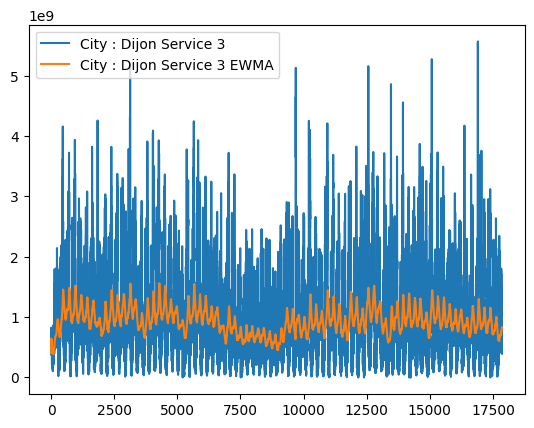

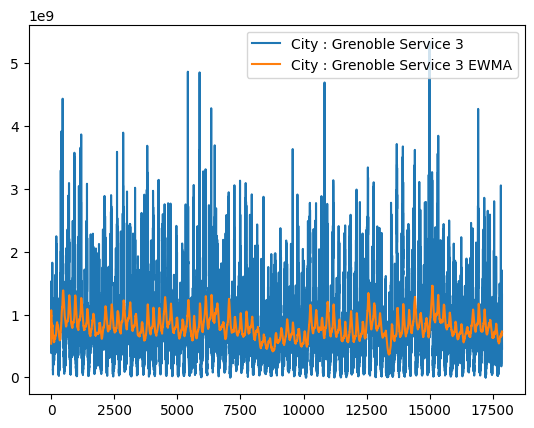

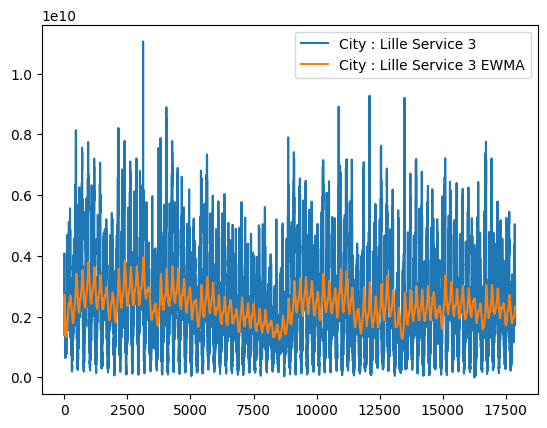

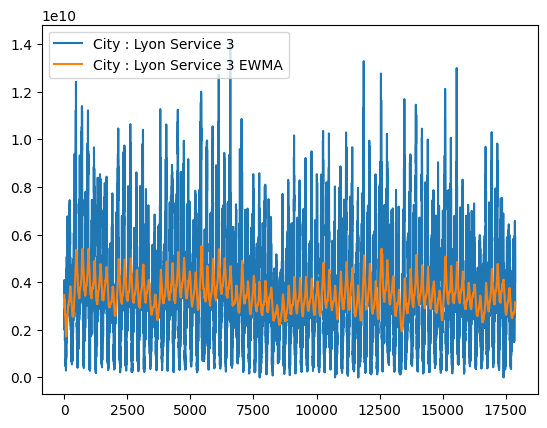

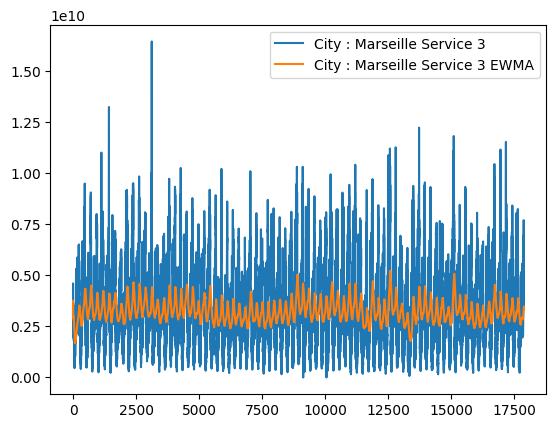

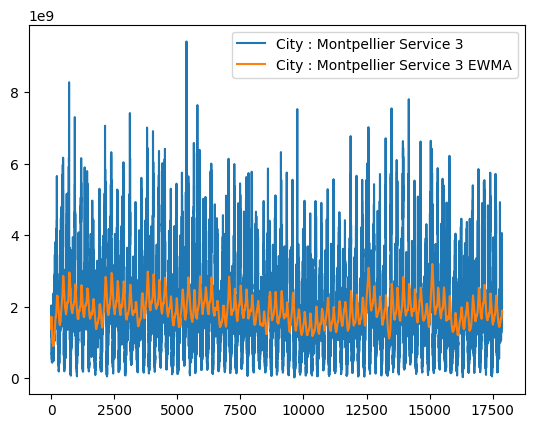

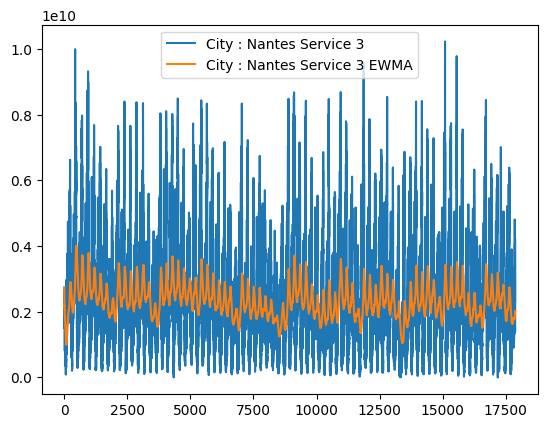

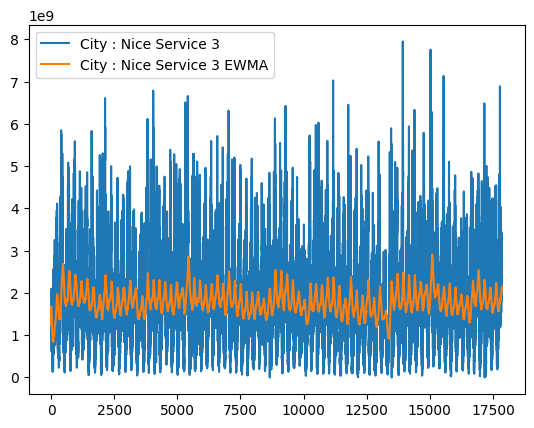

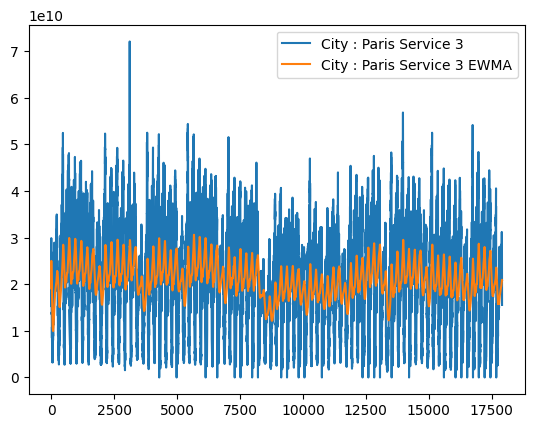

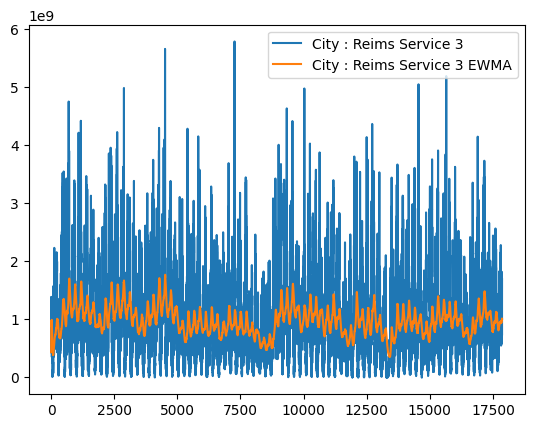

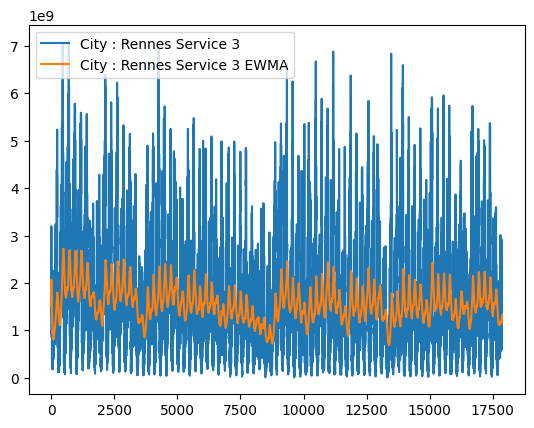

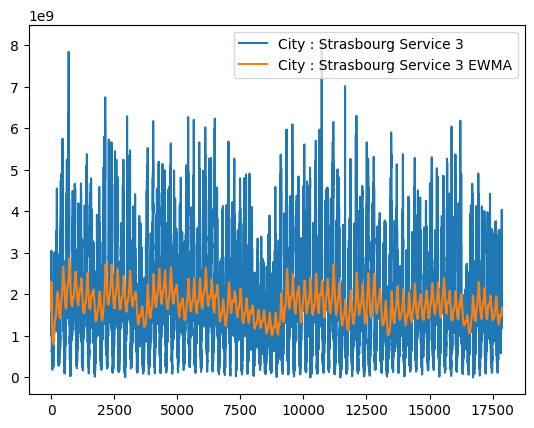

In [64]:
num_services = 5

for i in range(len(df_list)):
    for j in [3]:
    # for j in range(num_services):
        plt.figure()
        plt.plot(df_list[i].iloc[:,j], label=f'City : {cities[i]} Service {j}')
        plt.plot(ewma_df_list[i].iloc[:,j], label=f'City : {cities[i]} Service {j} EWMA')
        plt.legend()

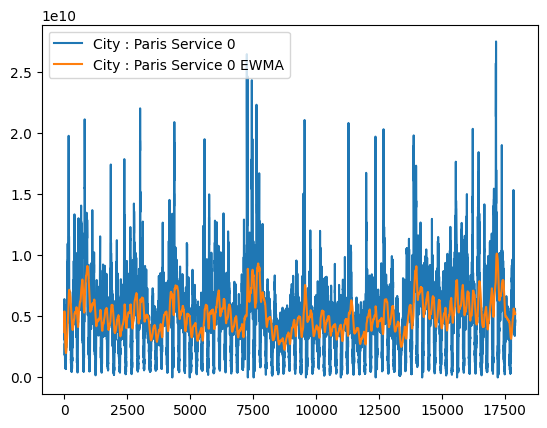

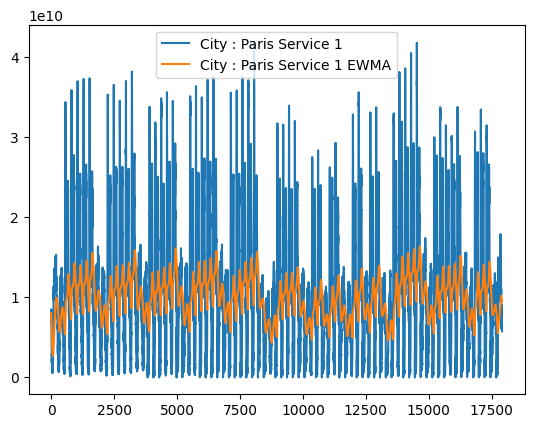

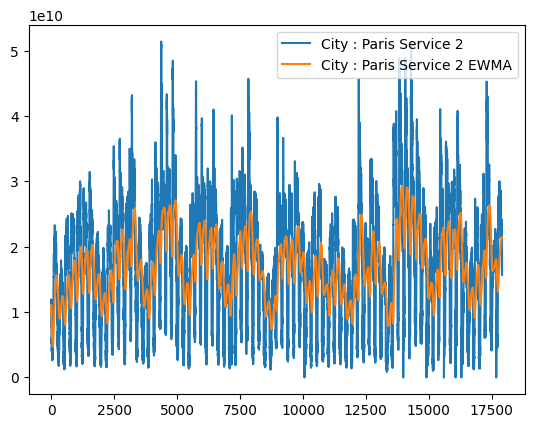

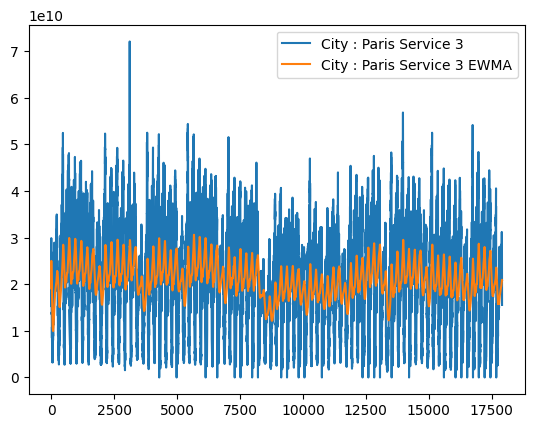

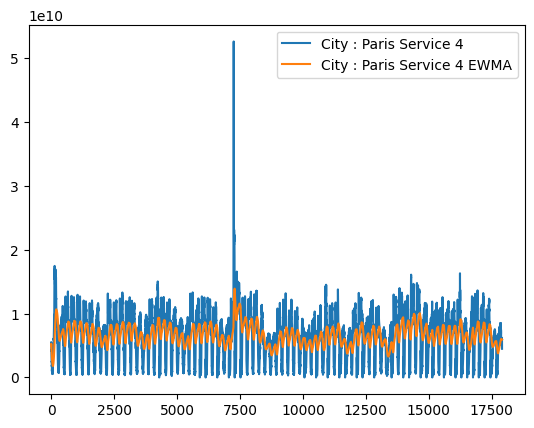

In [48]:
for i in range(bordeaux.columns.shape[0]):
    plt.figure()
    plt.plot(bordeaux.iloc[:,i], label=f'City : Paris Service {i}')
    plt.plot(ewma_pd.iloc[:,i], label=f'City : Paris Service {i} EWMA')
    plt.legend()